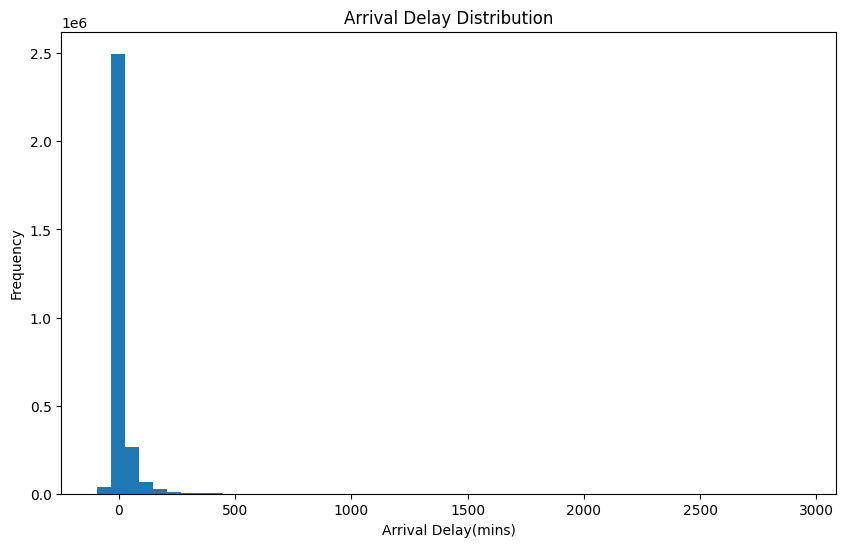

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

active_flights = pd.read_csv('../data/processed/active_flights.csv')

plt.figure(figsize=(10, 6))

plt.hist(active_flights['ARR_DELAY'],
         bins=50
)

plt.title('Arrival Delay Distribution')
plt.xlabel('Arrival Delay(mins)')
plt.ylabel('Frequency')

plt.show()

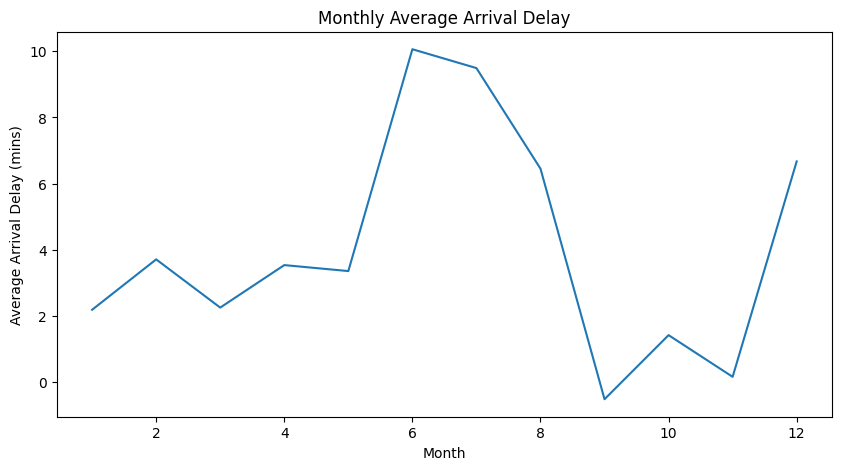

In [4]:
monthly_delay = (
    active_flights.groupby('MONTH')['ARR_DELAY']
    .mean()
)
monthly_delay.plot(figsize=(10,5))

plt.title('Monthly Average Arrival Delay')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (mins)')

plt.show()

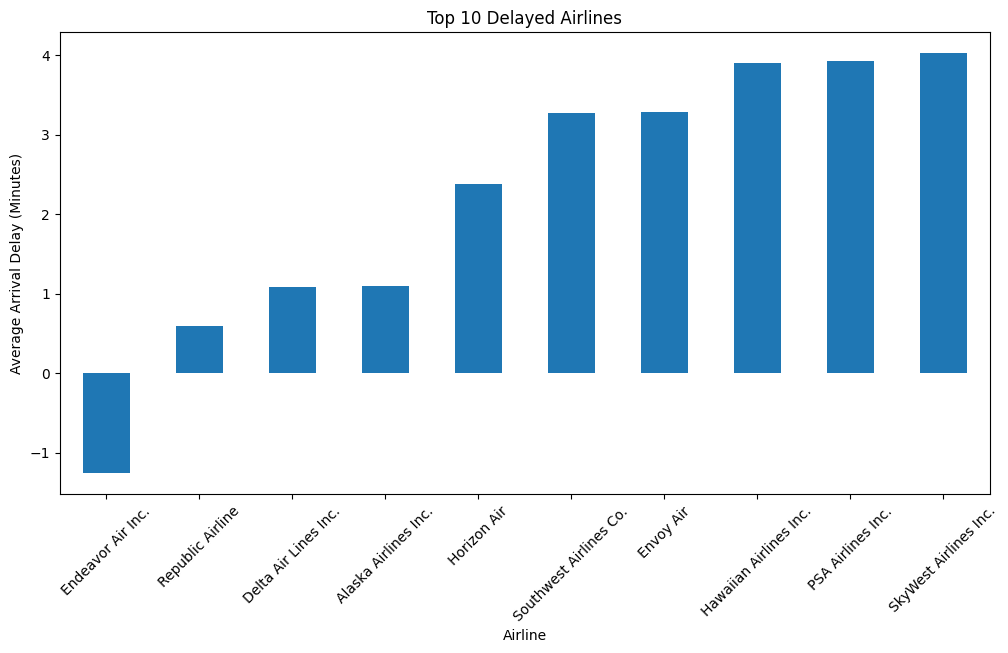

In [7]:
airline_delay = (
    active_flights.groupby('AIRLINE')['ARR_DELAY']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

airline_delay.plot(kind ='bar')

plt.title('Top 10 Delayed Airlines')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (Minutes)')

plt.xticks(rotation=45)
plt.show()
               

## Key Insights

- Skywest and PSA Airlines recorded the highest average arrival delays.
- Late aircraft and carrier-related issues appear to be major operational drivers.
- Lower-cost carriers may experience tighter scheduling constraints and operational bottlenecks.

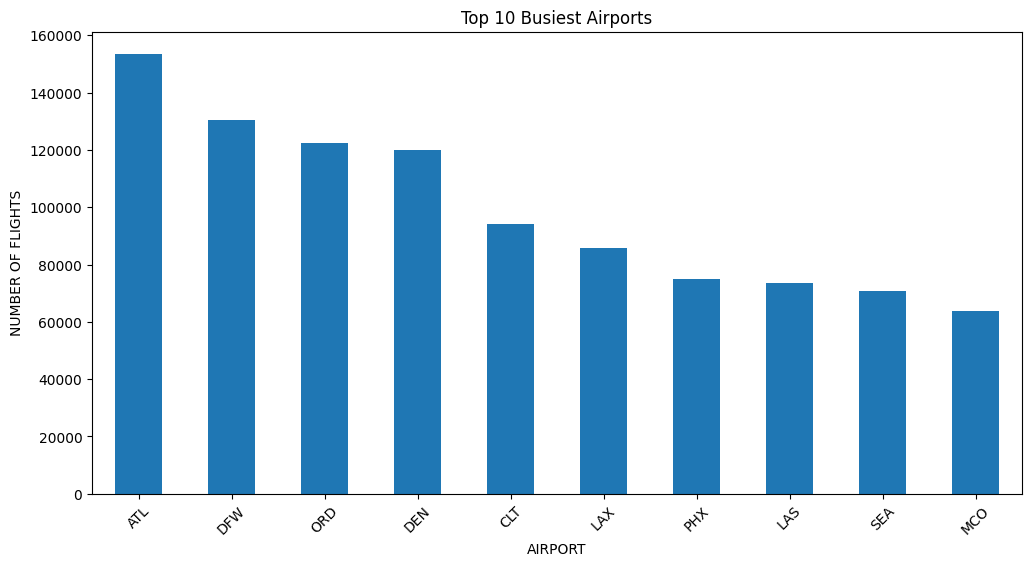

In [8]:
#Top 10 Busiest Airports
flights = pd.read_csv('../data/cleaned/flights_cleaned.csv')

busiest_airports = (flights['ORIGIN']
                    .value_counts()
                    .head(10)
                    )

plt.figure(figsize=(12,6))

busiest_airports.plot(kind='bar')

plt.title('Top 10 Busiest Airports')
plt.xlabel('AIRPORT')
plt.ylabel('NUMBER OF FLIGHTS')

plt.xticks(rotation=45)
plt.show()


## Key Insights

- ATL, DFW, and ORD handled the highest flight volumes.
- Major hub airports experience elevated congestion risk due to high operational throughput.
- Congestion-sensitive airports may contribute to cascading network delays.

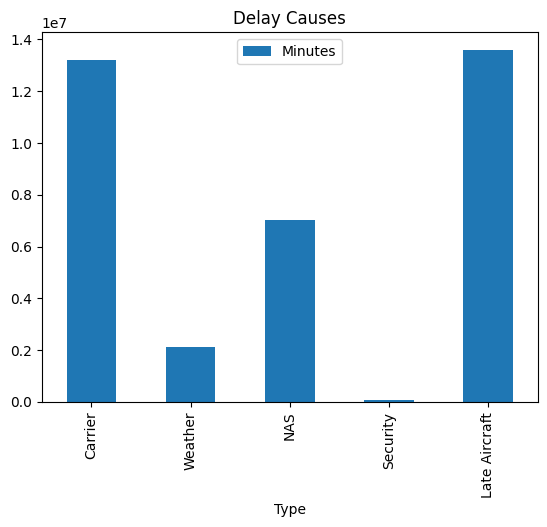

In [22]:
delay_causes = {
    'Carrier':
        active_flights['DELAY_DUE_CARRIER'].sum(),
    'Weather':
        active_flights['DELAY_DUE_WEATHER'].sum(),
    'NAS':
        active_flights['DELAY_DUE_NAS'].sum(),    
    'Security':
        active_flights['DELAY_DUE_SECURITY'].sum(),
    'Late Aircraft':
        active_flights['DELAY_DUE_LATE_AIRCRAFT'].sum(),
}

import pandas as pd
delay_df =pd.DataFrame(delay_causes.items(),
                       columns=['Type','Minutes'])

delay_df.plot(
    x='Type',
    y='Minutes',
    kind='bar'
)

plt.title('Delay Causes')
plt.show()

## Key Insights

- Late aircraft delay was the largest contributor to total disruption minutes.
- Carrier-related delays also contributed significantly to operational inefficiencies.
- Security-related delays had minimal operational impact.

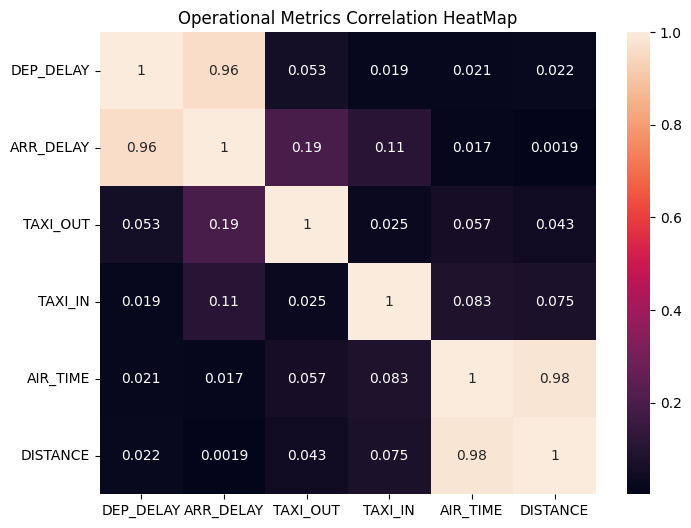

In [24]:
import seaborn as sns

corr_columns = [
    'DEP_DELAY',
    'ARR_DELAY',
    'TAXI_OUT',
    'TAXI_IN',
    'AIR_TIME',
    'DISTANCE'
]

corr_matrix = active_flights[corr_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True
)
plt.title('Operational Metrics Correlation HeatMap')
plt.show()